# Example with **DeCo**

>Tutorial author:Chenxi Wang（<sunnywcx@zju.deu.cn>）

In this tutorial, we use `LLaVA-1.5-7b` generate an image caption `DeCo`, we hope this tutorial could help you understand how to use the method DeCo on MLLMs, using the DeCo method with the LLaVA-1.5-7b as an example.

Model Hyparameters Config

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# pai
seed = 927
# model = 'llava-1.5'
model = 'minigpt4'
sample = False
temperature = -1
top_p = None
num_beams = 1
max_new_tokens = 512

#hyparams
use_jsd = True
alpha = 0.5
threshold_top_p = 0.9
threshold_top_k = 20
early_exit_layers=[i for i in range(20, 29, 1)]

In [2]:
import argparse
import json
import random
import numpy as np
import torch
import torch.nn.functional as F
import torch.backends.cudnn as cudnn
from constants import INSTRUCTION_TEMPLATE, SYSTEM_MESSAGE
from eval_data_loader import COCODataSet
from llava.utils import disable_torch_init
from model_loader import ModelLoader
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt

def setup_seeds(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    cudnn.benchmark = False
    cudnn.deterministic = True

/home/zhr/.conda/envs/deco/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


load model

In [3]:
setup_seeds(seed)
disable_torch_init()

model_loader = ModelLoader(model)

You are using the legacy behaviour of the <class 'transformers.models.llama.tokenization_llama.LlamaTokenizer'>. This means that tokens that come after special tokens will not be properly handled. We recommend you to read the related pull request available at https://github.com/huggingface/transformers/pull/24565


Initialization Model


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]/home/zhr/DeCo_JSD/transformers/modeling_utils.py:460: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return t

Loading Q-Former


/home/zhr/.conda/envs/deco/lib/python3.9/site-packages/huggingface_hub/file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/home/zhr/DeCo_JSD/minigpt4/models/base_model.py:216: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.ad

Loading Q-Former Done
Load MiniGPT-4 Checkpoint: /data1/zhr/checkpoints/minigpt4/vicuna-7b/prerained_minigpt4_7b.pth


/home/zhr/DeCo_JSD/minigpt4/models/minigpt4.py:193: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location="cpu")


Initialization Finished


In [4]:
image_id = 226988
# image_id = 46011
image_file = "/data1/zhr/datasets/coco2014/val2014/" + "COCO_val2014_"+str(image_id).zfill(12) + ".jpg"
image = Image.open(image_file).convert("RGB")
if model == "llava-1.5":
    image_tensor = model_loader.image_processor.preprocess(image, return_tensors='pt')
else:
    image_tensor = model_loader.image_processor(image).unsqueeze(0)

template = INSTRUCTION_TEMPLATE[model]
if model == "llava-1.5" or model == "shikra":
    template = SYSTEM_MESSAGE + template
query = ["Please help me describe the image in detail."]
questions, kwargs = model_loader.prepare_inputs_for_model(template, query, image_tensor)
# print("input_ids", kwargs["input_ids"].shape)
print("inputs_embeds", kwargs["inputs_embeds"].shape)
print("attention_mask", kwargs["attention_mask"].shape)
print("uncond_inputs_embeds", kwargs["uncond_inputs_embeds"].shape)
# print("uncond_input_ids", kwargs["uncond_input_ids"].shape)
print("uncond_attention_mask", kwargs["uncond_attention_mask"].shape)

/home/zhr/DeCo_JSD/minigpt4/models/base_model.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast(dtype=dtype)


inputs_embeds torch.Size([1, 56, 4096])
attention_mask torch.Size([1, 56])
uncond_inputs_embeds torch.Size([1, 26, 4096])
uncond_attention_mask torch.Size([1, 26])


inputs_embeds torch.Size([1, 56, 4096])

attention_mask torch.Size([1, 56])

/home/zhr/DeCo_JSD/minigpt4/models/base_model.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast(dtype=dtype)

In [5]:
with torch.inference_mode():
    output_dict, uncond_output_dict = model_loader.llm_model.generate(
        do_sample=sample,
        temperature=temperature,
        top_p=top_p,
        num_beams=num_beams,
        max_new_tokens=max_new_tokens,
        use_jsd=use_jsd,
        alpha = alpha,
        threshold_top_p=threshold_top_p, 
        threshold_top_k=threshold_top_k,
        early_exit_layers=early_exit_layers,
        return_dict=True,
        return_dict_in_generate=True,
        output_hidden_states=True,
        output_scores=True,
        **kwargs,
    )


uncond_input_ids tensor([[0]], device='cuda:0')


/home/zhr/DeCo_JSD/transformers/generation/utils.py:1285: UserWarning: You have modified the pretrained model configuration to control generation. This is a deprecated strategy to control generation and will be removed soon, in a future version. Please use a generation configuration file (see https://huggingface.co/docs/transformers/main_classes/text_generation )
  warnings.warn(


In [6]:

tokenizer = model_loader.tokenizer
output_ids = output_dict.sequences
if kwargs.get("input_ids", None) is not None:
    input_token_len = kwargs["input_ids"].shape[1]
else:
    input_token_len = 0
outputs = tokenizer.batch_decode(
        output_ids[:, input_token_len:], skip_special_tokens=True
    )[0]
outputs = outputs.split("###")[0].split("Assistant:")[-1].strip()

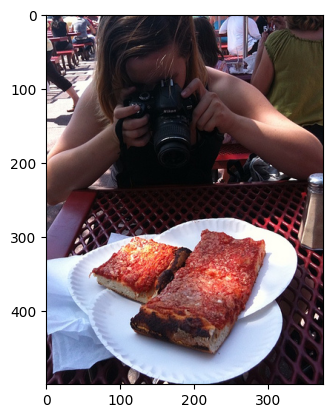

Ours:
 The image shows a woman taking a photo of two slices of pizza on two white plates on a red tablecloth. The woman is wearing a black tank top and black shorts, and she is holding a camera in her right hand. The background of the image is a park or outdoor area with trees and a fence in the distance. The pizza slices are covered with mozzarella cheese and tomato sauce, and they are cut into triangular pieces. The woman is looking down at the pizza and smiling.


In [7]:
plt.imshow(image)
plt.show()
# print("Original:\n", ori_outputs)
# print("\n")
# print("DeCo:\n", deco_outputs)
# print("\n")
print("Ours:\n", outputs)

In [16]:
start_idx = 10
outputs_tokens = output_ids[0, input_token_len:]
words = tokenizer.decode(outputs_tokens[start_idx:start_idx+50]).encode("unicode_escape").decode()
print(words)

two slices of pizza on two white plates on a red tablecloth. The woman is wearing a black tank top and black shorts, and she is holding a camera in her right hand. The background of the image is a


In [22]:
# token_idx = -68
# token_idx = -63
# token_idx = -42
token_idx = 9
threshold_top_k = 10
layer_logits = []
uncond_layer_logits = []

hidden_states = output_dict.hidden_states[token_idx]
uncond_hidden_states = uncond_output_dict.hidden_states[token_idx]

for layer_id in range(0, 33):
    if layer_id != 32:
        layer_output = model_loader.llm_model.model.norm(hidden_states[layer_id])
        uncond_layer_output = model_loader.llm_model.model.norm(uncond_hidden_states[layer_id])
    else:
        layer_output = hidden_states[layer_id].clone()
        uncond_layer_output = uncond_hidden_states[layer_id].clone()
    logits = model_loader.llm_model.lm_head(layer_output)[:,-1,:]
    uncond_logits = model_loader.llm_model.lm_head(uncond_layer_output)[:,-1,:]
    layer_logits.append(logits)
    uncond_layer_logits.append(uncond_logits)

stacked_layer_logits = torch.stack(layer_logits, dim=0) # shape: (num_layers, batch_size, vocab_size)
stacked_uncond_layer_logits = torch.stack(uncond_layer_logits, dim=0)

layer_softmax = F.softmax(stacked_layer_logits, dim=-1) # shape: (num_layers, batch_size, vocab_size)
uncond_layer_softmax = F.softmax(stacked_uncond_layer_logits, dim=-1)

layer_log_softmax = F.log_softmax(stacked_layer_logits, dim=-1)
uncond_layer_log_softmax =F.log_softmax(stacked_uncond_layer_logits, dim=-1)

final_layer_softmax = layer_softmax[-1, :, :]
final_layer_log_softmax = layer_log_softmax[-1, :, :]

In [23]:
probs = layer_softmax.squeeze()
uncond_probs = uncond_layer_softmax.squeeze()
# probs = layer_log_softmax.squeeze()
# uncond_probs = uncond_layer_log_softmax.squeeze()

candidate_tokens_probs, candidate_tokens_ids = torch.topk(probs[-1], dim=-1, k=threshold_top_k)

candidate_tokens_cumulative_probs = candidate_tokens_probs.cumsum(dim=-1)
candidate_tokens_indices = torch.searchsorted(candidate_tokens_cumulative_probs, threshold_top_p, right=False)
candidate_tokens_cutoff_idx = torch.min(candidate_tokens_indices + 1, torch.tensor(threshold_top_k))   

candidate_tokens_ids = candidate_tokens_ids[:candidate_tokens_cutoff_idx]

candidate_tokens_early_exit_probs = probs[:,candidate_tokens_ids]
uncond_candidate_tokens_early_exit_probs = uncond_probs[:,candidate_tokens_ids]

words = [tokenizer.decode(t.cpu()).encode("unicode_escape").decode() for t in candidate_tokens_ids]

final_softmax_score = F.softmax(output_dict.scores[token_idx][0], dim=-1)
final_tokens_probs, final_tokens_ids = torch.topk(final_softmax_score, dim=-1, k=threshold_top_k)

final_words = [tokenizer.decode(t.cpu()).encode("unicode_escape").decode() for t in final_tokens_ids]

print("top_p_candidate_tokens\n", words)
print(candidate_tokens_probs[:candidate_tokens_cutoff_idx])

print("final_tokens\n", final_words)
print(final_tokens_probs)

top_p_candidate_tokens
 ['a', 'two', 'her', 'herself']
tensor([0.6719, 0.1365, 0.0895, 0.0655], device='cuda:0', dtype=torch.float16)
final_tokens
 ['two', 'a', 'her', 'herself', '<0x00>', '</s>', '<0x01>', '<0x02>', '<unk>', '<s>']
tensor([8.9669e-01, 1.0021e-01, 2.8042e-03, 2.9614e-04, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00], device='cuda:0')


In [24]:
# cross layer JSD
M = 0.5 * (layer_softmax[...,candidate_tokens_ids] + uncond_layer_softmax[...,candidate_tokens_ids])

kl1 = F.kl_div(layer_log_softmax[...,candidate_tokens_ids], M, reduction='none').mean(-1) # shape: (num_layers, batch_size)
kl2 = F.kl_div(uncond_layer_log_softmax[...,candidate_tokens_ids], M, reduction='none').mean(-1)
js_divs = 0.5 * (kl1 + kl2)
cross_layer_js_divs = js_divs.mean(-1) # shape: (num_layers,)

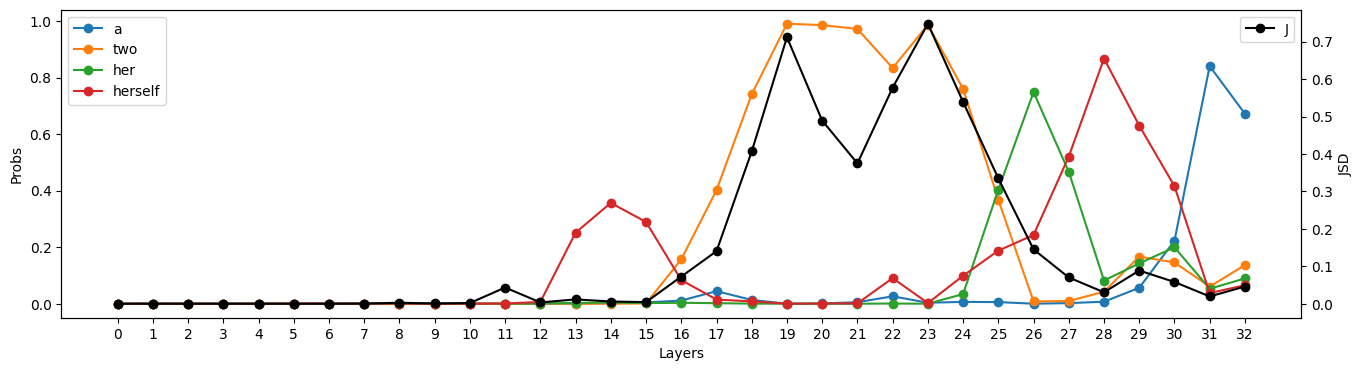

Max JS divergence idx:  23


In [25]:
fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(candidate_tokens_early_exit_probs.detach().cpu().numpy(), marker = 'o')
ax.set_xlabel("Layers")
ax.set_ylabel("Probs")
ax.set_xticks(range(33))
# ax.set_ylim(0, 1)
ax.legend(words, loc='upper left')

# jsd = cross_layer_js_divs.max() - cross_layer_js_divs
jsd = cross_layer_js_divs

ax2 = ax.twinx()
ax2.plot(jsd.detach().cpu().numpy(), marker = 'o', color = 'black')
ax2.set_ylabel("JSD")
ax2.legend("J")

plt.show()
print("Max JS divergence idx: ", jsd.argmax().item())

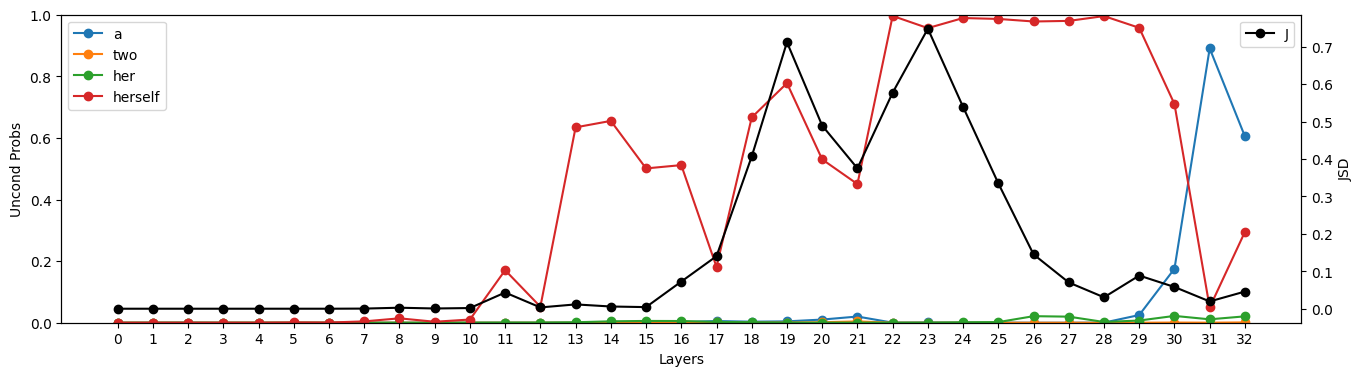

In [26]:
fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(uncond_candidate_tokens_early_exit_probs.detach().cpu().numpy(), marker = 'o')
ax.set_xlabel("Layers")
ax.set_ylabel("Uncond Probs")
ax.set_xticks(range(33))
ax.set_ylim(0, 1)
ax.legend(words, loc='upper left')

# jsd = cross_layer_js_divs.max() - cross_layer_js_divs
jsd = cross_layer_js_divs

ax2 = ax.twinx()
ax2.plot(jsd.detach().cpu().numpy(), marker = 'o', color = 'black')
ax2.set_ylabel("JSD")
ax2.legend("J")

plt.show()